# Pancreatic Cancer Detection Using Machine Learning

The objective of this notebook is to develop and evaluate machine learning models capable of distinguishing between healthy individuals, benign conditions and pancreatic cancer patients using clinical biomarker data.
Several classification algorithms will be trained and compared to identify the model that provides the best predictive performance while maintaining clinical interpretability.

## Data Loading

The validated pancreatic cancer dataset is loaded and prepared for machine learning modelling.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/pancreatic_600_risk123.csv")

df.head()

,sample_id,patient_cc,sample_o,age,sex,diagnosis,stage,plasma_C,creatinine,LYVE1,REG1B,TFF1,REG1A,CA19_9,CEA,bilirubin,glucose,urine_volume,urine_pH
0,S00111,Cohort1,CPTB,50,M,1,1,8.4501,0.5702,0.1307,79.1530,62.4789,602.2779,248.9139,0.5865,1.2925,108.63,98.4,5.61
1,S00420,Cohort2,BPTB,37,M,3,3,21.4297,0.8658,1.0011,257.8259,165.6953,690.4149,426.4674,8.6544,2.8729,102.61,118.0,6.34
2,S00566,Cohort2,CPTB,80,M,2,2,12.5803,0.8598,2.0098,71.1271,37.2556,721.6129,66.9918,7.6914,1.3359,72.08,7.4,6.14
3,S00078,Cohort1,BPTB,81,M,2,2,10.7277,1.1186,1.0485,114.6138,190.6209,725.6884,177.5647,4.3099,0.4216,120.19,98.8,5.46
4,S00182,Cohort1,BPTB,70,M,2,2,6.1396,1.2448,1.4906,268.5535,173.6363,713.5417,27.8392,4.6962,2.7625,91.05,84.7,6.83


In [ ]:
diagnosis_map = {
    1: "Healthy",
    2: "Benign",
    3: "Pancreatic Cancer"
}

df["diagnosis_label"] = (
    df["diagnosis"]
    .map(diagnosis_map)
)

## Data Preparation

The target variable and predictor variables are separated before splitting the dataset into training and testing subsets.

In [ ]:
X = df[
    [
        "age",
        "plasma_C",
        "creatinine",
        "LYVE1",
        "REG1B",
        "TFF1",
        "REG1A",
        "CA19_9",
        "CEA",
        "bilirubin",
        "glucose",
        "urine_volume",
        "urine_pH"
    ]
]

y = df["diagnosis"]

## Train-Test Split

The dataset is divided into training and testing subsets using stratified sampling to preserve class proportions.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (480, 13)
Testing set: (120, 13)


## Logistic Regression Baseline Model

Logistic Regression is used as a baseline classification model.
The model provides an interpretable benchmark against which more complex machine learning algorithms can later be compared.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

X_train_scaled.shape, X_test_scaled.shape

((480, 13), (120, 13))

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [ ]:
y_pred = log_reg.predict(
    X_test_scaled
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9750


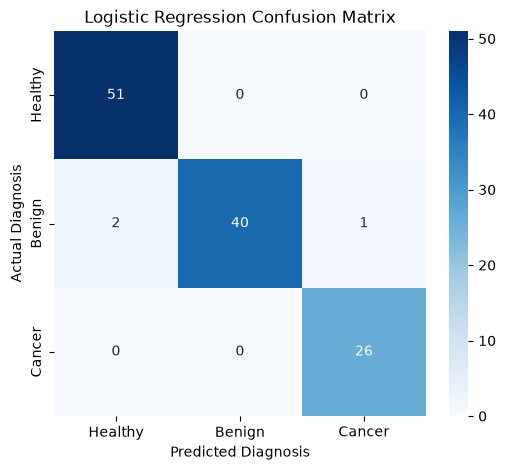

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy", "Benign", "Cancer"],
    yticklabels=["Healthy", "Benign", "Cancer"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")

plt.show()

### Findings

The Logistic Regression model achieved an accuracy of 97.5%.
The model correctly identified all pancreatic cancer patients in the test set and achieved perfect classification of healthy individuals.
Only three benign cases were misclassified, suggesting that the selected clinical biomarkers contain strong discriminatory information for pancreatic cancer detection.
These results indicate that even a simple linear classifier is capable of achieving excellent predictive performance on this dataset.

## Random Forest Classifier

Random Forest is trained as a non-linear ensemble model to evaluate whether more complex decision boundaries can improve diagnostic performance.
Its results are compared against the Logistic Regression baseline.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
y_pred_rf = rf.predict(
    X_test
)

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print(f"Accuracy: {accuracy_rf:.4f}")

Accuracy: 0.9667


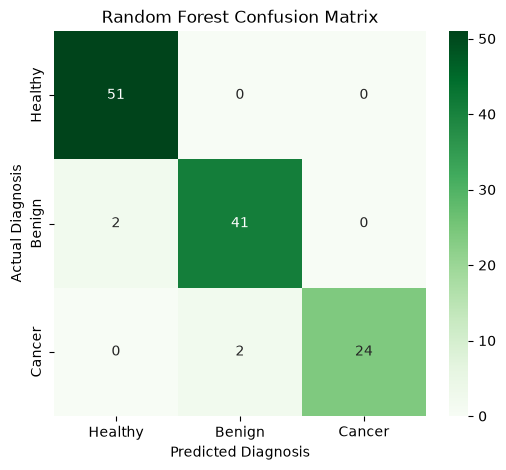

In [ ]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "Healthy",
        "Benign",
        "Cancer"
    ],
    yticklabels=[
        "Healthy",
        "Benign",
        "Cancer"
    ]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance

,Feature,Importance
6,REG1A,0.216352
4,REG1B,0.132047
1,plasma_C,0.111743
7,CA19_9,0.108605
5,TFF1,0.104638
8,CEA,0.085360
9,bilirubin,0.083933
3,LYVE1,0.074027
2,creatinine,0.029338
10,glucose,0.015586


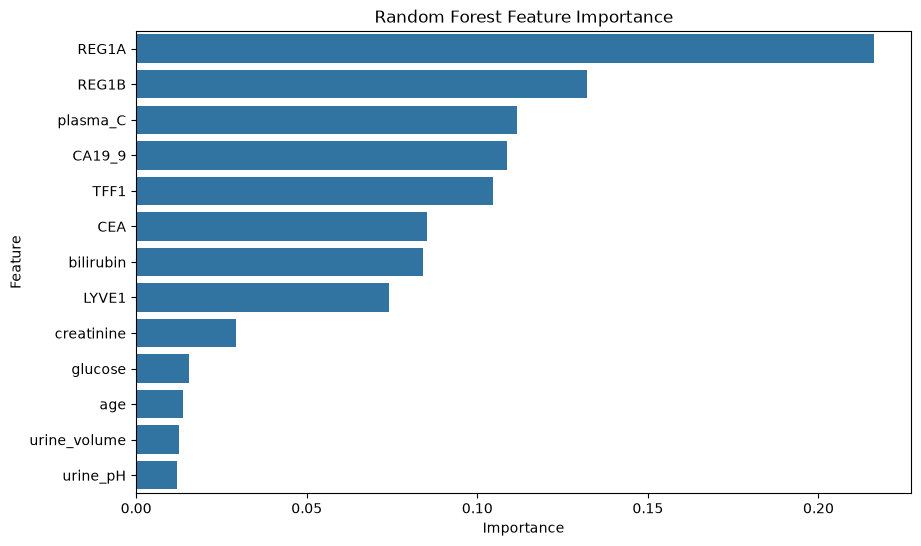

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

### Findings

The Random Forest classifier achieved an accuracy of 96.7%.
Although the model performed extremely well, Logistic Regression slightly outperformed it, achieving a higher overall accuracy of 97.5%.
Feature importance analysis identified REG1A, REG1B, plasma_C, CA19-9 and TFF1 as the most influential predictors, confirming the patterns observed during exploratory data analysis and feature validation.
These results suggest that pancreatic cancer diagnosis can be effectively predicted using a relatively small set of clinically relevant biomarkers.

## Model Comparison

The performance of Logistic Regression and Random Forest was compared using the same training and testing datasets.
Although both models achieved excellent predictive performance, Logistic Regression obtained the highest overall accuracy.

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.975000
1,Random Forest,0.966667


## Final Model Selection

Logistic Regression achieved the highest predictive performance with an accuracy of 97.5%.
In addition to outperforming Random Forest, Logistic Regression provides greater interpretability, which is particularly important in clinical applications.
For these reasons, Logistic Regression was selected as the final model.

## Clinical Interpretation

The analysis identified several biomarkers strongly associated with pancreatic cancer diagnosis.
REG1A, REG1B, plasma_C, CA19-9, TFF1 and CEA consistently emerged as the most influential variables during exploratory analysis and machine learning modelling.
These biomarkers may therefore represent valuable indicators for distinguishing pancreatic cancer patients from healthy individuals and benign cases.

## Key Predictive Biomarkers

Feature importance analysis consistently highlighted REG1A, REG1B, plasma_C, CA19-9, TFF1 and CEA as the most relevant predictors.
These biomarkers demonstrated strong relationships with pancreatic cancer diagnosis during exploratory analysis and remained highly influential during model development.

## Conclusions

Clinical biomarker measurements contain substantial information for pancreatic cancer detection.
Exploratory analysis revealed clear differences between healthy individuals, benign conditions and pancreatic cancer patients, particularly for REG1A, REG1B, CA19-9, TFF1 and CEA.
Among the evaluated machine learning algorithms, Logistic Regression achieved the strongest performance with an accuracy of 97.5%.
These findings suggest that machine learning models can effectively support pancreatic cancer classification using routine biomarker data.